# Simple polynomial Regression

deg = 0<br>
h(theta)(x) = beta_0 + beta_1 * x


### quadratic eq: ax^2 + bx + c = 0
### discriminant: D = b^2 - 4ac
see the data points or non relationship data points are not in a straight line, they are in a curve. so we can use polynomial regression to fit the curve.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
x = 6*np.random.rand(100,1)
y = 0.5*x**2 + x + 2 + np.random.rand(100,1)

#### what x and y look like
#### Answer: x and y are numpy arrays with 100 rows and 1 column. x contains random values between 0 and 6, while y is generated using a quadratic equation with some added random noise. The relationship between x and y is nonlinear, as y is a function of x squared.

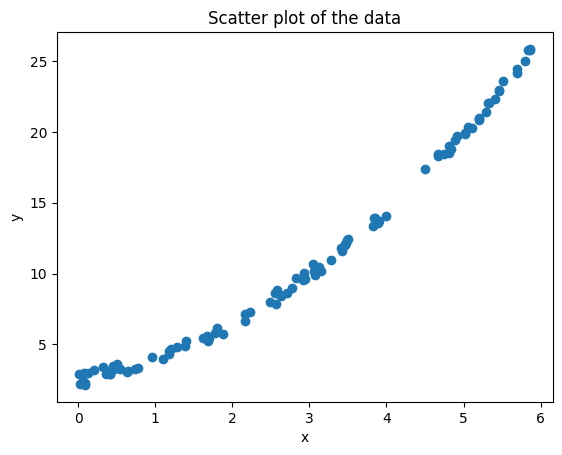

In [3]:
## Visualize the data
plt.scatter(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of the data')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [6]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()


In [7]:
X_train

array([[0.36520544],
       [0.02166072],
       [3.45844317],
       [5.85930883],
       [5.86628991],
       [4.83645035],
       [1.19901934],
       [3.84881581],
       [0.4102996 ],
       [0.20811704],
       [3.40369109],
       [2.82627716],
       [2.23292149],
       [0.32605802],
       [0.07488182],
       [3.04287934],
       [5.02253976],
       [4.74532119],
       [1.6864868 ],
       [2.61262236],
       [2.62701025],
       [1.88044517],
       [5.46043863],
       [2.16321916],
       [3.84359997],
       [3.8867846 ],
       [3.07627727],
       [3.42317228],
       [4.6620193 ],
       [0.41905013],
       [4.81543444],
       [3.27596401],
       [0.08257618],
       [5.31519888],
       [0.45095908],
       [4.90821784],
       [4.66333961],
       [3.15305893],
       [5.69371099],
       [5.83701804],
       [2.93679969],
       [5.51204927],
       [1.102356  ],
       [0.01692075],
       [2.71311795],
       [0.50902927],
       [3.06437004],
       [3.903

In [8]:
regression.fit(X_train, Y_train)

LinearRegression()

In [9]:
from sklearn.metrics import r2_score
sscore = r2_score(Y_test, regression.predict(X_test))

In [10]:
sscore

0.9362712384041357

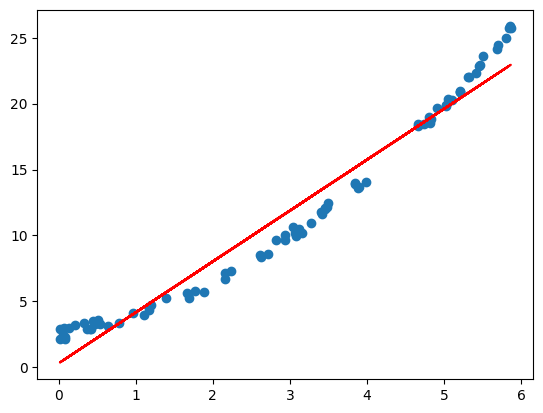

In [12]:
plt.plot(X_train,regression.predict(X_train), color='red')
plt.scatter(X_train,Y_train)

### we will try with this <br>
### htheta(x) = theta0 + theta1*x + theta2*x^2

# from sklearn.preprocessing import PolynomialFeatures

In [13]:
###Lets polynomial tranformation
from sklearn.preprocessing import PolynomialFeatures

In [14]:
poly = PolynomialFeatures(degree=2, include_bias=True)


what is degree means = degree is the power to which the input features are raised in the polynomial transformation. For example, if degree=2, the transformation will include terms like x^2, x*y, and y^2 (if there are multiple features). If degree=3, it will include terms like x^3, x^2*y, x*y^2, and y^3. The degree determines the complexity of the polynomial model being created.



what is mean by include_bias= it means including a bias term (intercept) in the polynomial features.

In [18]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

fit_transform is used to fit the model and then transform the data. It is used when we want to apply the same transformation to the training and test data.

the transformation in teh fit_tranform means that it will fit the polynomial features to the data and then transform the data into the new polynomial feature space. This means that it will create new features based on the original features, such as x^2, x^3, etc., up to the specified degree. The include_bias=True parameter adds a bias term (intercept) to the feature set.

what is mean bu tranforming of data means 
tranforming of data means converting the data into a different format or structure. In the context of machine learning, it often refers to applying mathematical operations to the features of the dataset to create new features that may better capture the underlying patterns in the data.

In [19]:
X_train_poly

array([[1.00000000e+00, 3.65205443e-01, 1.33375015e-01],
       [1.00000000e+00, 2.16607242e-02, 4.69186972e-04],
       [1.00000000e+00, 3.45844317e+00, 1.19608292e+01],
       [1.00000000e+00, 5.85930883e+00, 3.43315000e+01],
       [1.00000000e+00, 5.86628991e+00, 3.44133573e+01],
       [1.00000000e+00, 4.83645035e+00, 2.33912520e+01],
       [1.00000000e+00, 1.19901934e+00, 1.43764737e+00],
       [1.00000000e+00, 3.84881581e+00, 1.48133831e+01],
       [1.00000000e+00, 4.10299602e-01, 1.68345764e-01],
       [1.00000000e+00, 2.08117045e-01, 4.33127044e-02],
       [1.00000000e+00, 3.40369109e+00, 1.15851130e+01],
       [1.00000000e+00, 2.82627716e+00, 7.98784261e+00],
       [1.00000000e+00, 2.23292149e+00, 4.98593838e+00],
       [1.00000000e+00, 3.26058019e-01, 1.06313832e-01],
       [1.00000000e+00, 7.48818179e-02, 5.60728665e-03],
       [1.00000000e+00, 3.04287934e+00, 9.25911465e+00],
       [1.00000000e+00, 5.02253976e+00, 2.52259056e+01],
       [1.00000000e+00, 4.74532

In [20]:
X_test_poly

array([[1.00000000e+00, 6.39862218e-01, 4.09423658e-01],
       [1.00000000e+00, 3.48208960e+00, 1.21249480e+01],
       [1.00000000e+00, 2.77765001e+00, 7.71533958e+00],
       [1.00000000e+00, 2.56341016e+00, 6.57107163e+00],
       [1.00000000e+00, 2.91270487e+00, 8.48384966e+00],
       [1.00000000e+00, 7.37021012e-01, 5.43199972e-01],
       [1.00000000e+00, 2.49038648e+00, 6.20202482e+00],
       [1.00000000e+00, 3.91047824e-01, 1.52918401e-01],
       [1.00000000e+00, 4.88567506e+00, 2.38698208e+01],
       [1.00000000e+00, 1.79774649e+00, 3.23189244e+00],
       [1.00000000e+00, 1.62467467e+00, 2.63956778e+00],
       [1.00000000e+00, 1.27765646e+00, 1.63240602e+00],
       [1.00000000e+00, 1.38223270e+00, 1.91056723e+00],
       [1.00000000e+00, 3.82503976e+00, 1.46309292e+01],
       [1.00000000e+00, 5.28479289e+00, 2.79290358e+01],
       [1.00000000e+00, 4.49665319e+00, 2.02198899e+01],
       [1.00000000e+00, 1.69950058e+00, 2.88830224e+00],
       [1.00000000e+00, 2.58036

In [21]:
from sklearn.metrics import r2_score
regression.fit(X_train_poly, Y_train)


LinearRegression()

In [22]:
y_pred = regression.predict(X_test_poly)
score = r2_score(Y_test, y_pred)
score

0.997491340527083

In [23]:
print(regression.coef_)

[[0.         0.90957499 0.51290957]]


In [25]:
print("R2 score for linear regression:", sscore)
print("R2 score for polynomial regression:", score)

R2 score for linear regression: 0.9362712384041357
R2 score for polynomial regression: 0.997491340527083


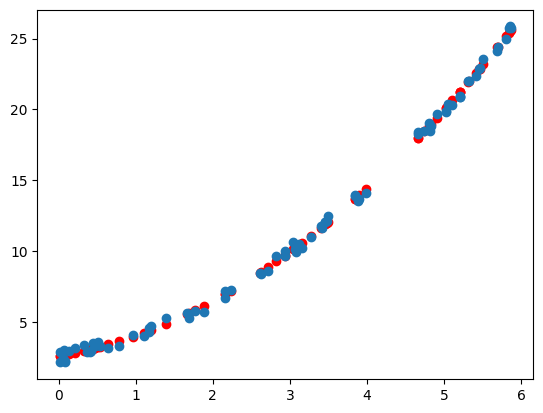

In [27]:
plt.scatter(X_train,regression.predict(X_train_poly), color='red')
plt.scatter(X_train,Y_train)

In [28]:
poly = PolynomialFeatures(degree=3, include_bias=True)

In [29]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [30]:
from sklearn.metrics import r2_score
regression.fit(X_train_poly, Y_train)

LinearRegression()

In [31]:
y_pred = regression.predict(X_test_poly)
score = r2_score(Y_test, y_pred)
score

0.9974848523487047

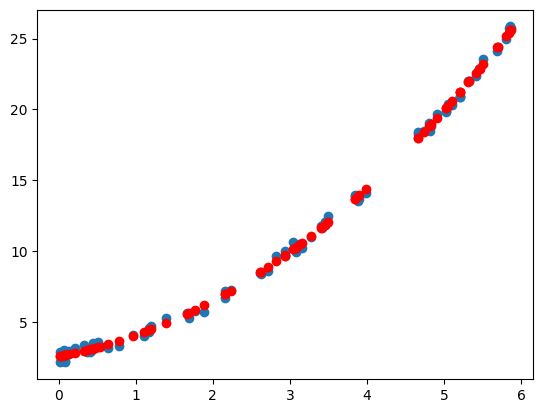

In [32]:
plt.scatter(X_train,Y_train)
plt.scatter(X_train,regression.predict(X_train_poly), color='red')


In [34]:
#3 prediction for new dat set
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)

In [35]:
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

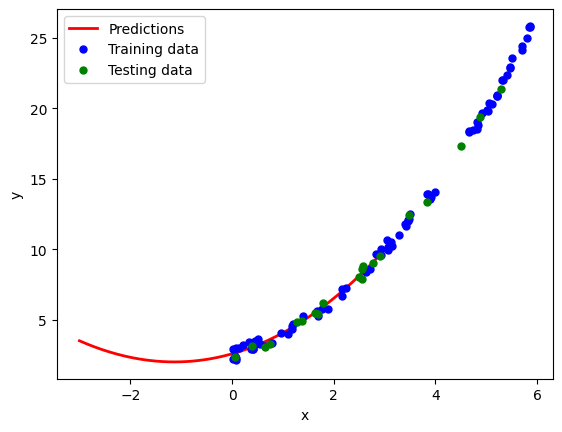

In [40]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new,y_new,"r-",linewidth = 2,label="Predictions")
plt.plot(X_train,Y_train,"b.",markersize=10,label="Training data")
plt.plot(X_test,Y_test,"g.",markersize=10,label="Testing data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

### pipeline Concepts

In [41]:
from sklearn.pipeline import Pipeline


X_new = np.linspace(-3, 3,200).reshape(200,1)
the aboev equation is used to create a new set of x values between -3 and 3, with 200 evenly spaced points. The reshape(200,1) is used to convert the 1D array of x values into a 2D array with 200 rows and 1 column, which is the required format for input to the polynomial regression model.

In [42]:
def poly_regression(degree):
    X_new = np.linspace(-3,3,200).reshape(200,1)
    poly_features = PolynomialFeatures(degree = degree,include_bias =True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([
        ('poly_features',poly_features),
        ('lin_reg',lin_reg)
    ])
    poly_regression.fit(X_train,Y_train)
    y_pred_new = poly_regression.predict(X_new)
    plt.plot(X_new,y_pred_new ,"r-",label ="Degree "+str(degree),linewidth = 2)
    plt.plot(X_train,Y_train,"b.",markersize=10,label="Training data")
    plt.plot(X_test,Y_test,"g.",markersize=10,label="Testing data")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()
    
    
    

then why we used fit_transform for training data and only transform for test data?
and even at the top at the starting i mean why we used fit_transform for training data and only transform for test data?
Bacause we want to learn the parameters of the polynomial transformation from the training data, and then apply the same transformation to the test data. The fit_transform method is used to fit the polynomial features to the training data and transform it, while the transform method is used to apply the same transformation to the test data without fitting it again. This ensures that the test data is transformed using the same parameters learned from the training data, which is important for making accurate predictions.

then why we didnt use fit_tranform in the poly_regression function?
because we are using pipeline, and pipeline will take care of the fit_transform for us. We just need to call fit on the pipeline, and it will automatically call fit_transform on the polynomial features and then fit the linear regression model.

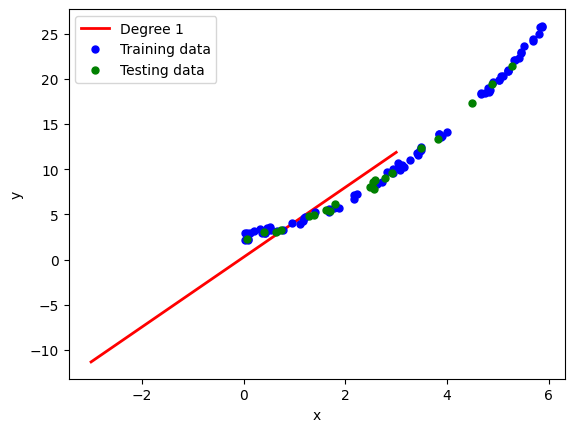

In [44]:
poly_regression(1)

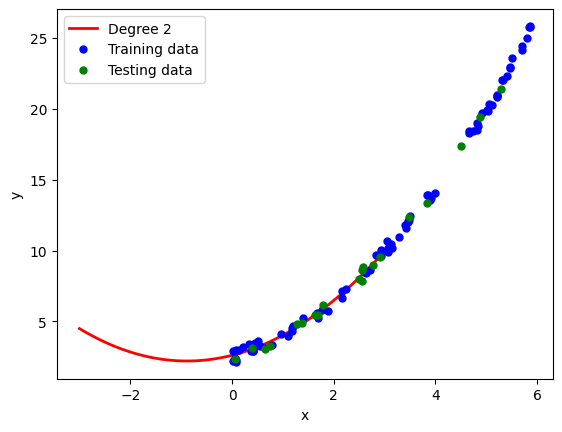

In [45]:
poly_regression(2)

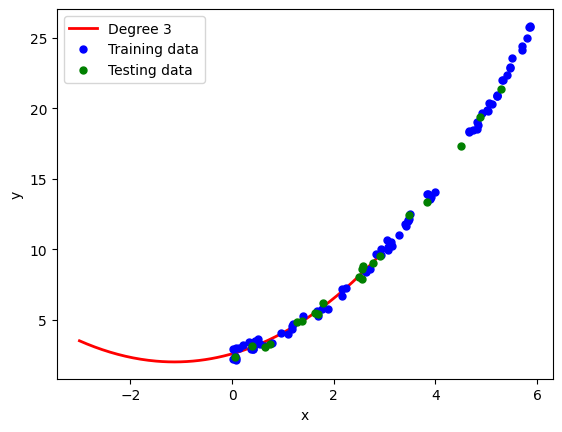

In [46]:
poly_regression(3)

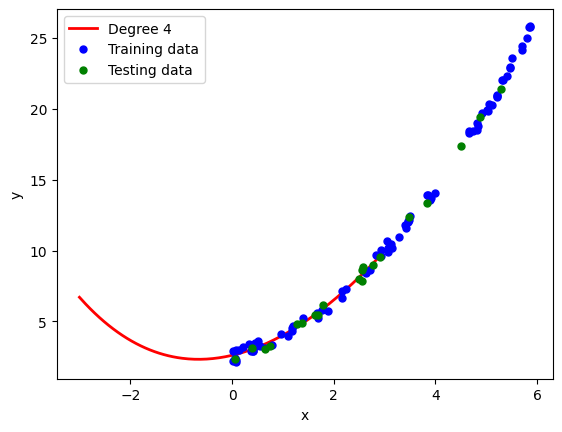

In [47]:
poly_regression(4)

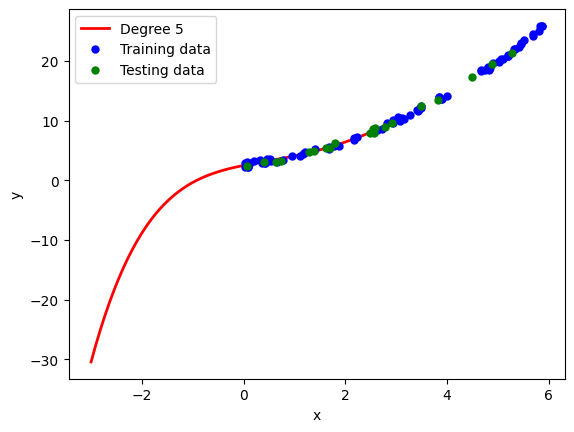

In [48]:
poly_regression(5)

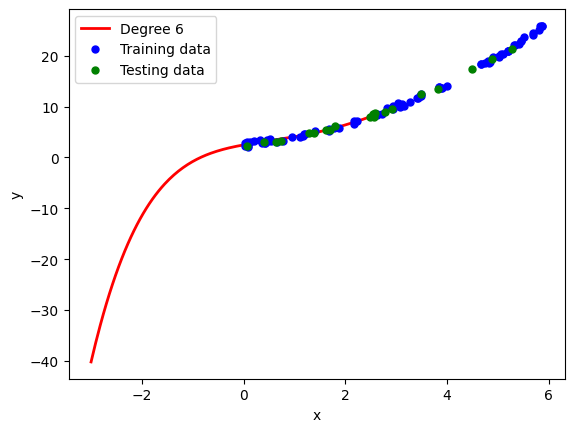

In [49]:
poly_regression(6)